In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.0.1
pandas: 2.3.1


In [3]:
# 웹 서버 접속 로그 생성 (가상) — 한 줄이 통째로 문자열
np.random.seed(7)
n_logs = 1500
ips = [f"203.0.113.{k}" for k in range(1, 60)] + [f"198.51.100.{k}" for k in range(1, 60)]
paths = ["/", "/products", "/products/123", "/products/456", "/cart",
         "/checkout", "/login", "/search", "/api/orders"]
methods = ["GET", "GET", "GET", "POST"]
statuses = [200, 200, 200, 200, 200, 404, 500, 301]

# 시각: 7일치, 초 단위로 무작위 발생 후 정렬
log_times = pd.to_datetime("2025-03-01") + pd.to_timedelta(
    np.sort(np.random.randint(0, 7 * 24 * 3600, n_logs)), unit="s")

lines = []
for i in range(n_logs):
    ip = np.random.choice(ips)
    ts_str = log_times[i].strftime("%d/%b/%Y:%H:%M:%S")   # 12/Jan/2025:10:15:32
    m = np.random.choice(methods)
    p = np.random.choice(paths)
    st = np.random.choice(statuses)
    sz = np.random.randint(200, 5000)
    lines.append(f'{ip} - - [{ts_str}] "{m} {p} HTTP/1.1" {st} {sz}')

web_logs = pd.DataFrame({"raw": lines})
print("웹 로그 생성 완료:", web_logs.shape)
print("\n[원본 로그 한 줄은 이렇게 생겼습니다]")
for line in web_logs["raw"].head(3):
    print(line)

웹 로그 생성 완료: (1500, 1)

[원본 로그 한 줄은 이렇게 생겼습니다]
203.0.113.39 - - [01/Mar/2025:00:01:14] "GET / HTTP/1.1" 200 2371
198.51.100.21 - - [01/Mar/2025:00:02:24] "GET / HTTP/1.1" 301 284
198.51.100.17 - - [01/Mar/2025:00:02:28] "GET /search HTTP/1.1" 200 1448


In [4]:
# 시나리오 1 — 정규식으로 6개 필드를 한 번에 추출
pattern = (
    r"(?P<ip>\d+\.\d+\.\d+\.\d+)"        # IP: 숫자.숫자.숫자.숫자
    r" - - \["                            # 고정 구분 부분
    r"(?P<ts>[^\]]+)"                     # 시각: ] 가 아닌 글자들
    r"\] \""                              # ] 와 따옴표
    r"(?P<method>\w+) "                   # 방식: GET/POST
    r"(?P<path>\S+)"                      # 경로: 공백 아닌 글자들
    r"[^\"]*\" "                          # HTTP/1.1 부분 건너뛰기
    r"(?P<status>\d+) "                   # 상태 코드
    r"(?P<size>\d+)"                      # 응답 크기
)
logs = web_logs["raw"].str.extract(pattern)
print("추출된 표:", logs.shape)
print(logs.head())
print("\n추출 실패(어느 한 칸이라도 NaN) 행 수:", logs.isna().any(axis=1).sum())

추출된 표: (1500, 6)
              ip                    ts method       path status  size
0   203.0.113.39  01/Mar/2025:00:01:14    GET          /    200  2371
1  198.51.100.21  01/Mar/2025:00:02:24    GET          /    301   284
2  198.51.100.17  01/Mar/2025:00:02:28    GET    /search    200  1448
3   203.0.113.35  01/Mar/2025:00:03:56    GET      /cart    404  3921
4   203.0.113.47  01/Mar/2025:00:14:29    GET  /products    500  2580

추출 실패(어느 한 칸이라도 NaN) 행 수: 0


In [5]:
# 시나리오 2 — 타입 정리(날짜·숫자) + dt 부품
logs["ts"] = pd.to_datetime(logs["ts"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
logs["status"] = logs["status"].astype(int)
logs["size"] = logs["size"].astype(int)

# dt 부품: 시각(hour)과 요일
logs["hour"] = logs["ts"].dt.hour
logs["dow_name"] = logs["ts"].dt.day_name()

print("정리 후 자료형:")
print(logs.dtypes)
print()
print(logs[["ip", "ts", "method", "path", "status", "hour", "dow_name"]].head())

# 시나리오 2 — 상태 코드·인기 경로 빠르게 집계
print("[상태 코드 분포]")
print(logs["status"].value_counts())

error_rate = (logs["status"] >= 400).mean() * 100   # 4xx·5xx 비율
print(f"\n오류 응답(4xx·5xx) 비율: {error_rate:.1f}%")

print("\n[요청이 많은 경로 TOP 5]")
print(logs["path"].value_counts().head())

정리 후 자료형:
ip                  object
ts          datetime64[ns]
method              object
path                object
status               int64
size                 int64
hour                 int32
dow_name            object
dtype: object

              ip                  ts method       path  status  hour  dow_name
0   203.0.113.39 2025-03-01 00:01:14    GET          /     200     0  Saturday
1  198.51.100.21 2025-03-01 00:02:24    GET          /     301     0  Saturday
2  198.51.100.17 2025-03-01 00:02:28    GET    /search     200     0  Saturday
3   203.0.113.35 2025-03-01 00:03:56    GET      /cart     404     0  Saturday
4   203.0.113.47 2025-03-01 00:14:29    GET  /products     500     0  Saturday
[상태 코드 분포]
status
200    964
301    188
404    178
500    170
Name: count, dtype: int64

오류 응답(4xx·5xx) 비율: 23.2%

[요청이 많은 경로 TOP 5]
path
/                184
/search          175
/cart            173
/products/456    171
/products        168
Name: count, dtype: int64


ts
2025-03-01 00:00:00     9
2025-03-01 01:00:00    11
2025-03-01 02:00:00     8
2025-03-01 03:00:00    12
2025-03-01 04:00:00    11
                       ..
2025-03-07 19:00:00    17
2025-03-07 20:00:00    11
2025-03-07 21:00:00     7
2025-03-07 22:00:00    21
2025-03-07 23:00:00     6
Freq: h, Name: ip, Length: 168, dtype: int64


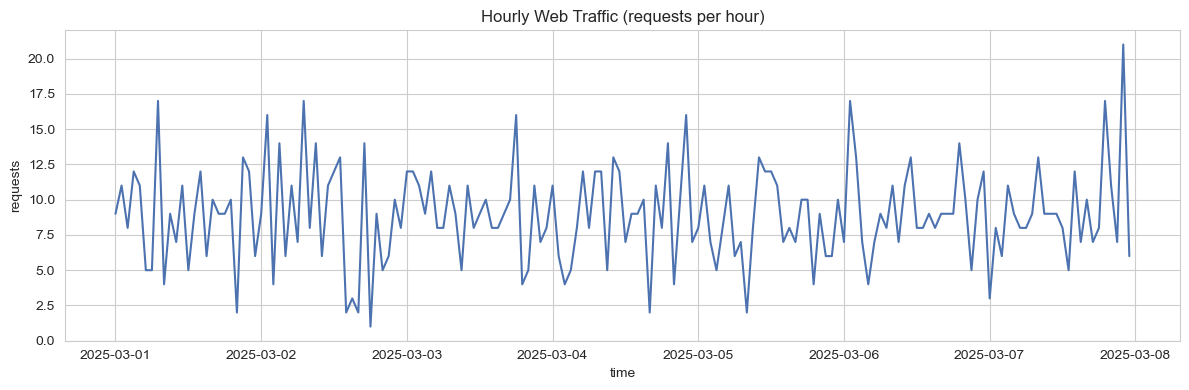

가장 트래픽이 많았던 시간대 TOP 3:
ts
2025-03-07 22:00:00    21
2025-03-02 07:00:00    17
2025-03-06 01:00:00    17
Name: ip, dtype: int64


In [9]:
# 시나리오 3 — 시간대별 트래픽 (resample 'h')
log_ts = logs.dropna(subset=["ts"]).set_index("ts").sort_index()
hourly_traffic = log_ts["ip"].resample("h").count()    # 시간당 요청 수
print(hourly_traffic)

plt.figure(figsize=(12, 4))
plt.plot(hourly_traffic.index, hourly_traffic.values, color="#4C72B0")
plt.title("Hourly Web Traffic (requests per hour)")
plt.xlabel("time"); plt.ylabel("requests")
plt.tight_layout(); plt.show()

print("가장 트래픽이 많았던 시간대 TOP 3:")
print(hourly_traffic.sort_values(ascending=False).head(3))

# 모두마켓 웹 트래픽 — 로그 분석 리포트

## 1. 데이터 개요
- 로그 줄 수: 1500줄
- 기간: 2025-03-01 ~ 2025-03-07
- 추출 필드: ip, ts, method, path, status, size

## 2. 파싱 (어떻게 표로 만들었나)
- 사용한 정규식 패턴의 핵심: IP는 `\d+\.\d+...`, 시각은 `[^\]]+` 로 추출
- 날짜 형식: %d/%b/%Y:%H:%M:%S 로 파싱, 실패 0건

## 3. 트래픽 요약
- 총 요청 수: 1500
- 오류 응답(4xx·5xx) 비율: 23.2%
- 요청 많은 경로 TOP 3: /, /search , /cart

## 4. 시간 패턴 (리샘플링에서 읽은 것)
- 트래픽이 가장 몰린 시간대: 22시
- 요일/시간대 특징: 

## 5. 다음 분석 제안
- IP별 요청 수 조사하기
- 오류가 특정 경로에서 많이 나는건지 조사해보기